### London Bicycles

#### Fetch data from BigQuery using SQLAlchemy and load it into a pandas DataFrame for EDA.

In [ ]:
# pip install seaborn in 'elt', polars not installed
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
#import os
# Optional: Set the environment variable for authentication if not already set
# os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "/path/to/your/keyfile.json"

# Define your project, dataset, and table names
project_id = 'dsai-001'
credentials_path = ''

# Create the engine, specifying project and/or credentials path
engine = create_engine(f'bigquery://{project_id}', credentials_path=credentials_path)

E0000 00:00:1773374767.430358   16496 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773374767.430414   16496 instrument.cc:563] Metric with name 'grpc.resource_quota.calls_rejected' registered more than once. Ignoring later registration.
E0000 00:00:1773374767.430417   16496 instrument.cc:563] Metric with name 'grpc.resource_quota.connections_dropped' registered more than once. Ignoring later registration.
E0000 00:00:1773374767.430419   16496 instrument.cc:563] Metric with name 'grpc.resource_quota.instantaneous_memory_pressure' registered more than once. Ignoring later registration.
E0000 00:00:1773374767.430420   16496 instrument.cc:563] Metric with name 'grpc.resource_quota.memory_pressure_control_value' registered more than once. Ignoring later registration.
/tmp/ipykernel_16496/477066457.py:15: SADeprecationWarning: The dbapi() classmethod on dialect classes has been renamed to import_d

##### Fetch aggregated data for rental

In [2]:
# Define data source query
dataset_id = "london_bicycles"
table_id = "fact_hire_summary"

query = f"""
SELECT * FROM `{project_id}.{dataset_id}.{table_id}`
"""

# Use pandas to read SQL query results into DataFrame
df_rental = pd.read_sql(query, con=engine)
print(df_rental.info())

/home/jasmine/miniconda3/envs/elt/lib/python3.11/site-packages/google/cloud/bigquery/client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3202411 entries, 0 to 3202410
Data columns (total 9 columns):
 #   Column              Dtype 
---  ------              ----- 
 0   rental_year         int64 
 1   rental_month        int64 
 2   start_hour          int64 
 3   part_of_day         object
 4   part_of_week        object
 5   season              object
 6   start_station_id    int64 
 7   start_station_name  object
 8   total_rentals       int64 
dtypes: int64(5), object(4)
memory usage: 219.9+ MB
None


In [3]:
df_rental.describe(include='all')

,rental_year,rental_month,start_hour,part_of_day,part_of_week,season,start_station_id,start_station_name,total_rentals
count,3.202411e+06,3.202411e+06,3.202411e+06,3202411,3202411,3202411,3.202411e+06,3202411,3.202411e+06
unique,NaN,NaN,NaN,4,2,4,NaN,953,NaN
top,NaN,NaN,NaN,Night,Weekday,Summer,NaN,"Bethnal Green Road, Shoreditch",NaN
freq,NaN,NaN,NaN,853319,1655304,823580,NaN,4652,NaN
mean,2.018617e+03,6.524607e+00,1.235917e+01,NaN,NaN,NaN,5.964752e+03,NaN,2.596355e+01
std,2.328808e+00,3.424432e+00,6.648253e+00,NaN,NaN,NaN,3.923670e+04,NaN,4.675614e+01
min,2.015000e+03,1.000000e+00,0.000000e+00,NaN,NaN,NaN,1.000000e+00,NaN,1.000000e+00
25%,2.017000e+03,4.000000e+00,7.000000e+00,NaN,NaN,NaN,2.090000e+02,NaN,4.000000e+00
50%,2.019000e+03,7.000000e+00,1.300000e+01,NaN,NaN,NaN,4.320000e+02,NaN,1.300000e+01
75%,2.021000e+03,9.000000e+00,1.800000e+01,NaN,NaN,NaN,6.500000e+02,NaN,3.100000e+01


##### Fetch data for stations

In [4]:
# Define data source query
dataset_id = "london_bicycles_star"
table_id = "dim_station"

query = f"""
SELECT *
FROM `{project_id}.{dataset_id}.{table_id}`
"""

In [5]:
# Use pandas to read SQL query results into DataFrame
df_station = pd.read_sql(query, con=engine)
df_station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             800 non-null    int64  
 1   latitude       800 non-null    float64
 2   longitude      800 non-null    float64
 3   name           800 non-null    object 
 4   bikes_count    800 non-null    int64  
 5   docks_count    800 non-null    int64  
 6   nbEmptyDocks   800 non-null    int64  
 7   terminal_name  800 non-null    object 
 8   install_date   712 non-null    object 
 9   start_total    800 non-null    int64  
 10  end_total      800 non-null    int64  
dtypes: float64(2), int64(6), object(3)
memory usage: 68.9+ KB


In [6]:
df_station.head()

,id,latitude,longitude,name,bikes_count,docks_count,nbEmptyDocks,terminal_name,install_date,start_total,end_total
0,792,51.505461,-0.104541,"Blackfriars Road, Southwark",0,42,41,300214,2016-02-08,94990,96275
1,427,51.513971,-0.092940,"Cheapside, Bank",0,43,42,22180,2011-07-15,260835,275040
2,215,51.519069,-0.088285,"Moorfields, Moorgate",0,54,54,1092,2010-07-19,188383,207020
3,313,51.517344,-0.138073,"Wells Street, Fitzrovia",0,38,38,3495,2010-07-23,137194,140120
4,266,51.501027,-0.180246,"Queen's Gate (North), Kensington",0,41,41,1204,2010-07-21,108079,107220


In [7]:
df_station.describe(include='all')

,id,latitude,longitude,name,bikes_count,docks_count,nbEmptyDocks,terminal_name,install_date,start_total,end_total
count,800.000000,800.000000,800.000000,800,800.000000,800.000000,800.00000,800,712,800.000000,800.000000
unique,NaN,NaN,NaN,800,NaN,NaN,NaN,800,228,NaN,NaN
top,NaN,NaN,NaN,"Blackfriars Road, Southwark",NaN,NaN,NaN,300214,2010-07-21,NaN,NaN
freq,NaN,NaN,NaN,1,NaN,NaN,NaN,1,35,NaN,NaN
mean,432.536250,51.505977,-0.127511,NaN,12.690000,26.330000,12.68625,NaN,NaN,97653.268750,97099.560000
std,250.092281,0.020348,0.055243,NaN,9.798158,8.782084,10.34222,NaN,NaN,67983.743121,71115.751619
min,1.000000,51.452997,-0.236770,NaN,0.000000,0.000000,0.00000,NaN,NaN,0.000000,0.000000
25%,213.750000,51.493116,-0.172106,NaN,3.000000,20.000000,4.00000,NaN,NaN,59081.250000,55971.750000
50%,442.500000,51.509191,-0.129698,NaN,12.000000,24.000000,12.00000,NaN,NaN,84639.000000,81635.500000
75%,650.250000,51.520970,-0.090691,NaN,20.000000,30.000000,18.25000,NaN,NaN,120065.000000,117729.000000


#### Visualisations

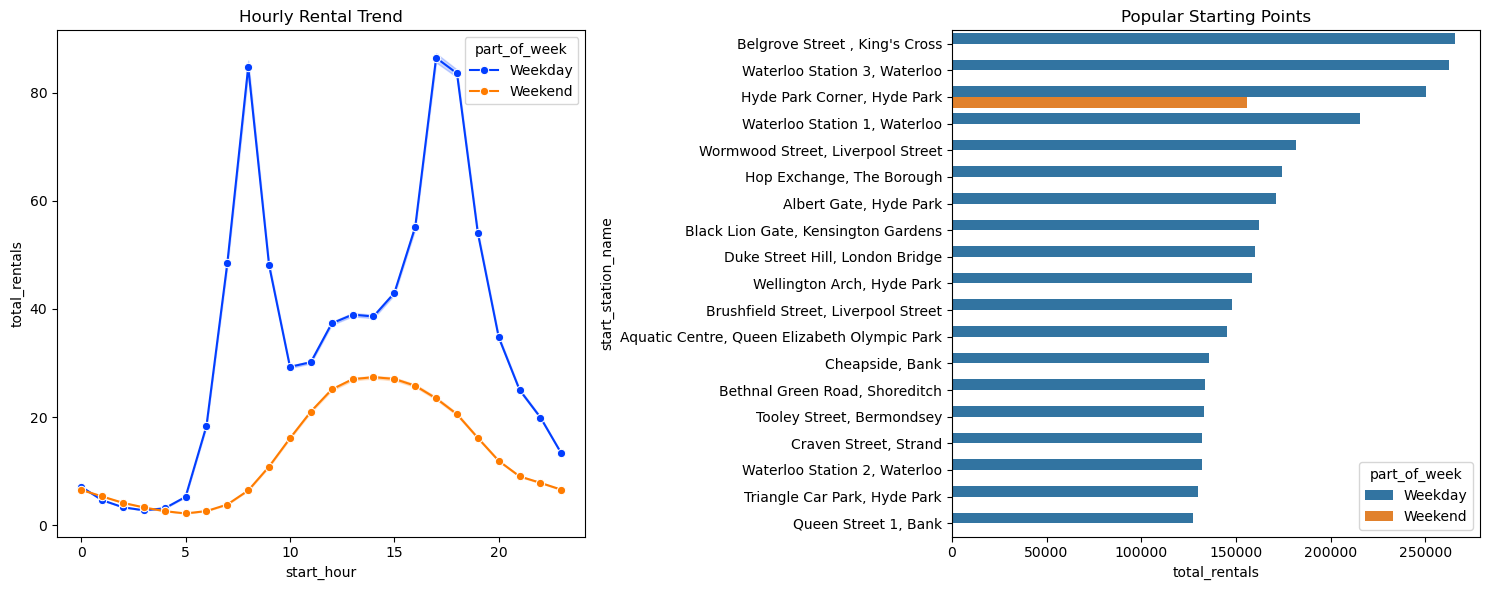

In [ ]:
# Look into the latest 5 years of data (last data point at Jan'23)
filtered_df = df_rental[(df_rental['rental_year']>=2018) & (df_rental['rental_year'] <= 2022)]
grouped_df = filtered_df.groupby(['start_station_name', 'part_of_week']).sum('total_rentals').sort_values(by='total_rentals', ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Hourly rental trend
sns.lineplot(data=filtered_df, x='start_hour', y='total_rentals', hue='part_of_week', 
             palette='bright', marker='o', ax=axes[0])
axes[0].set_title('Hourly Rental Trend')

# Rental volume by stations
sns.barplot(data=grouped_df, x='total_rentals', y='start_station_name', hue='part_of_week', ax=axes[1])
axes[1].set_title('Popular Starting Points')

plt.tight_layout()
plt.show()

**Findings:**  
- Weekday usage peaked at 8AM and 5PM.
- Generally, Weekday usage surpassed Weekend usage at all times.


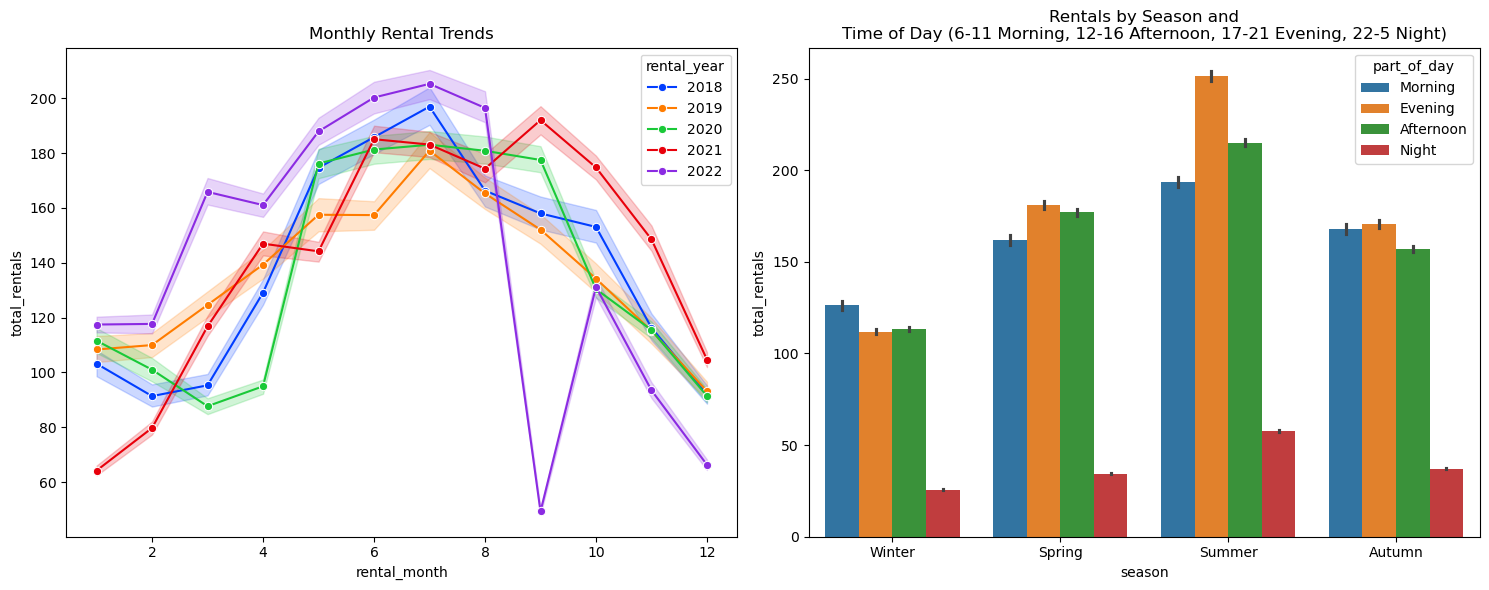

In [ ]:
# Look into the latest 5 years of data
# filtered_df = df_rental[(df_rental['rental_year']>=2018) & (df_rental['rental_year'] <= 2022)]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Monthly rental trends by year
sns.lineplot(data=filtered_df, x='rental_month', y='total_rentals', hue='rental_year', 
             palette='bright', legend='full', marker='o', ax=axes[0])
axes[0].set_title('Monthly Rental Trends')

# Rentals by Season and Time of Day
sns.barplot(data=df_rental, x='season', y='total_rentals', hue='part_of_day', ax=axes[1])
axes[1].set_title('Rentals by Season and\nTime of Day (6-11 Morning, 12-16 Afternoon, 17-21 Evening, 22-5 Night)')

plt.tight_layout() # Prevents overlapping labels
plt.show()

**Findings:**  
- Revenue is seasonal and opportunity is concentrated at certain times of a day.
- 2022 September: National mourning following the death of Queen Elizabeth II.
- 2022 October: Dockless competitors expanded services, providing flexible & non-station based usage --> potentially lowered docked bicycles usage.

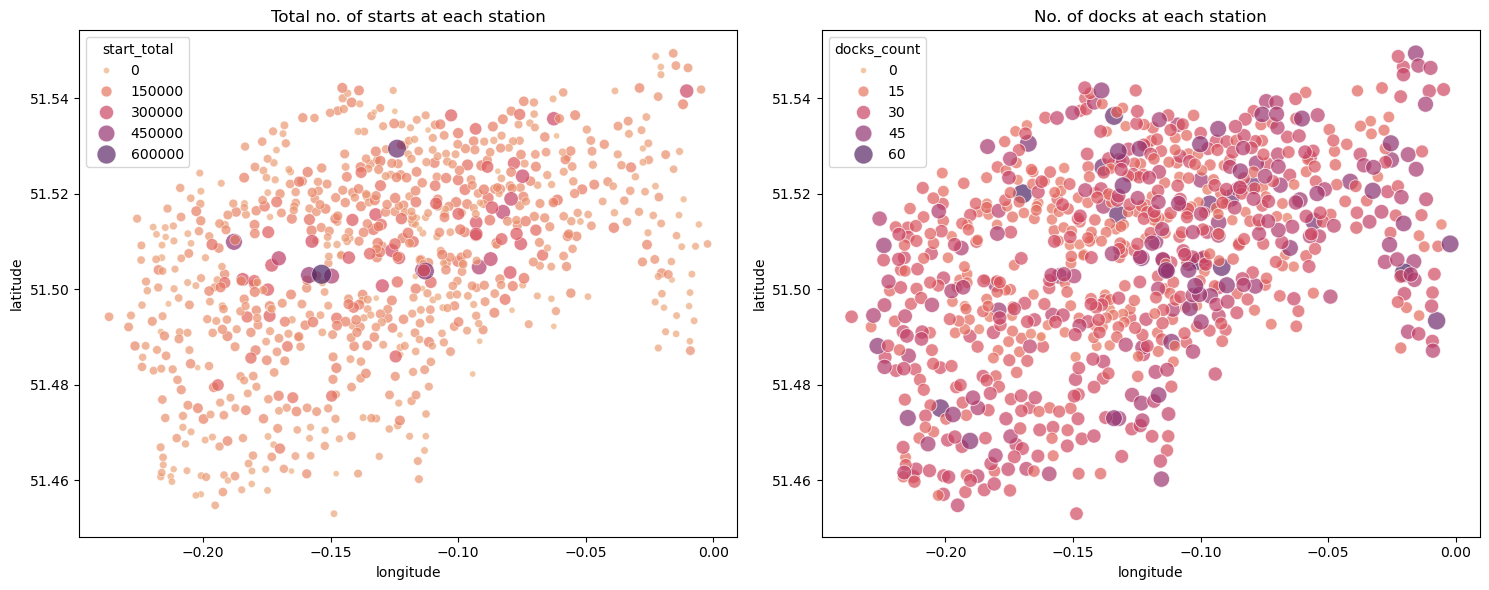

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total no. of starts at each station
sns.scatterplot(
    data=df_station,
    x='longitude',
    y='latitude',
    hue='start_total',  # Color represents total no. of starts
    size='start_total', # Size represents total no. of starts
    sizes=(20, 200),    # Range of point sizes
    palette='flare',  # Color palette (inferno, magma, plasma, viridis also good)
    alpha=0.7,          # Transparency for overlap
    ax=axes[0]
)
axes[0].set_title('Total no. of starts at each station')

# Docks count at each station
sns.scatterplot(
    data=df_station,
    x='longitude',
    y='latitude',
    hue='docks_count',  # Color represents bike count
    size='docks_count', # Size represents bike count
    sizes=(20, 200),    # Range of point sizes
    palette='flare',  # Color palette (inferno, magma, plasma, viridis also good)
    alpha=0.7,          # Transparency for overlap
    ax=axes[1]
)
axes[1].set_title('No. of docks at each station')

plt.tight_layout()
plt.show()

**Findings:**  
- Higher usage volume originated in central area.
- However, the number of docks at each station is not aligned with the usage volume.

Text(0, 0.5, 'Station')

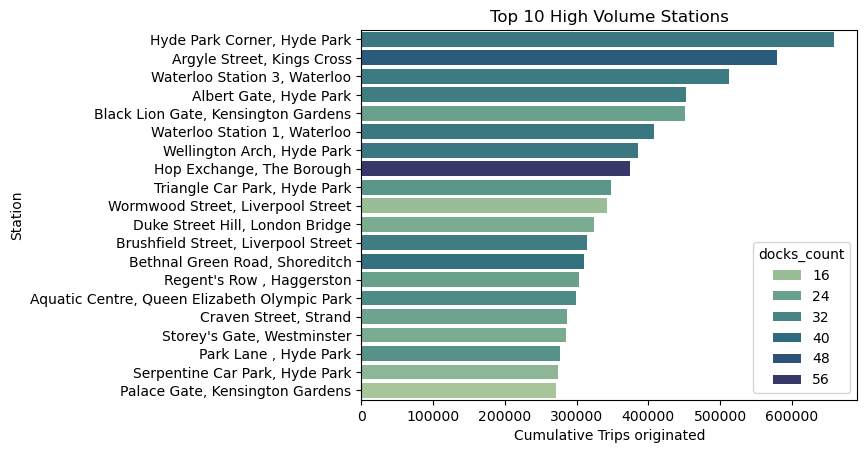

In [ ]:
# Stations with high number of trips originated
top20_stations = df_station.sort_values(by='start_total', ascending=False).head(20)
sns.barplot(data=top20_stations, x='start_total', y='name', hue='docks_count', palette='crest')
plt.title('Top 10 High Volume Stations')
plt.xlabel('Cumulative Trips originated')
plt.ylabel('Station')

In [ ]:
# station id/name in hire & station tables not totally aligned
# merged_df = pd.merge(grouped_df, df_station, how='left', left_on='start_station_name', right_on='name')
# sns.barplot(data=merged_df, x='total_rentals', y='name', hue='docks_count', palette='crest', errorbar=None)